The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


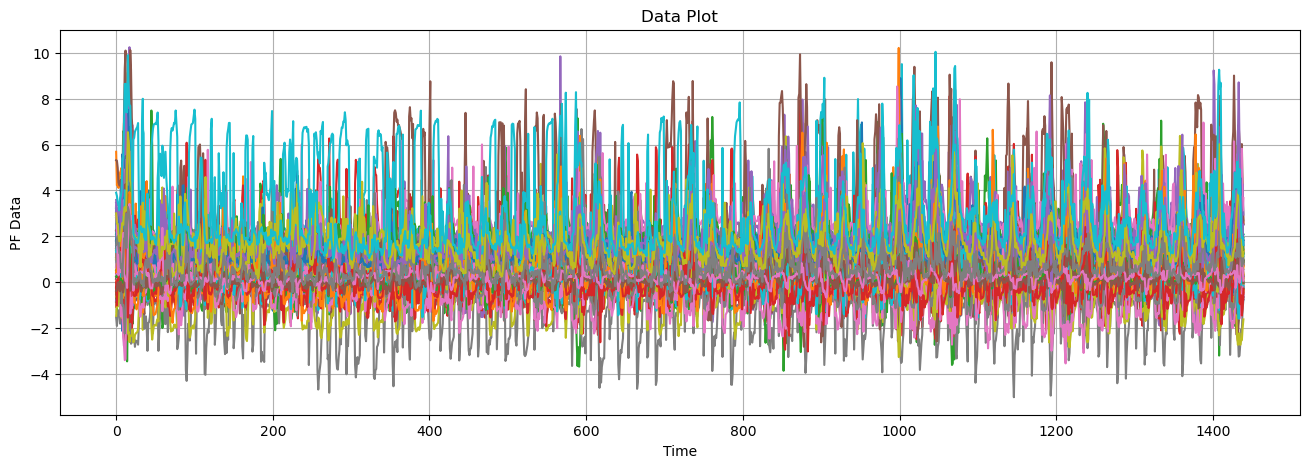

In [ ]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.graph as graph
import lib.threshold as threshold
import lib.residual as resd
import lib.subBase as subBase
import lib.utils as utils
import lib.ac_se_fdia as ac_se_fdia
from skimage.filters import threshold_li
import pandas as pd
import lib.cycle_space as csp
import tqdm
from scipy.stats import chi2
from lib.read_ac_pf_csv import read_ac_power_flow_data
from scipy.linalg import qr
import pandapower as pp
import pandapower.networks as nw

powerID= 118
IEEENames= ["IEEE 14", "IEEE 30", "IEEE 57", "IEEE 118"]
case_map = {14: nw.case14, 30: nw.case30, 57: nw.case57, 118: nw.case118}
net = case_map[powerID]()
outPutFile= False
# Load MATLAB file
file_name= f'matpower/test_data/DC_case{powerID}_.mat' #14, 118, 57, 30
DC_file= f'data/paper_2/results{powerID}.xlsx' # DC
_, _, H, A, _, _, _, _= ioFile.read_mat_power(file_name, normalize= False)
pfData, _=ioFile.read_excel_power(DC_file, id1= 0, id2= 0)
m= H.shape[0]
n= H.shape[1]
#
param= np.sum(np.abs(H), axis= 1, keepdims= True)/2
m= H.shape[0]
n= H.shape[1]
rankH= n-1
stdOfNoise= 1e-4
numTrain= m+ 1
#
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noiseE= noiseVector*stdOfNoise
pfDataE= pfData.copy()+noiseE
pfDataTrain= pfData[:m, :]
#
plotTimeSeries= True
if plotTimeSeries:
    plt.figure(figsize=(16, 5))
    for i in range(m):
        plt.plot(pfData[:, i], label=i)
    # plt.yscale("log")
    plt.title('Data Plot')
    plt.xlabel('Time')
    plt.ylabel('PF Data')
    plt.grid(True)
    plt.show()

In [216]:
#dc power flow cycle basis learning
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noiseE= noiseVector*5e-2
print(f"SNR: {utils.calculate_snr(pfData, noiseE):.2f} dB")
pfDataDcNoise= pfData+noiseE
wholeRight= pfDataDcNoise[:numTrain, :].T.dot(pfDataDcNoise[:numTrain, :])
spaningTreeList, leftLinksSet= csp.get_spanning_tree(pfDataDcNoise[:numTrain, :], rankH, m)
cycleList, treeLinks= csp.get_cycle_and_tree(spaningTreeList, leftLinksSet, wholeRight, m)
print("tree:", treeLinks)
csp.check_spanning_tree(A, spaningTreeList, rankH)
csp.check_tree_links(A, rankH, treeLinks)
csp.check_cycle_list(A, cycleList)
_, cSpaceClean, _= resd.cycle_residual(pfData[:numTrain, :], rankH, m, pfData[numTrain:, :], cycleList)
NcSpaceClean= cSpaceClean@np.linalg.pinv(cSpaceClean.T@cSpaceClean)@cSpaceClean.T

SNR: 28.93 dB
tree: {32, 51, 44, 31}
spaningTreeList correct: True
treeLinks correct: False
missing: []
extra: [31, 32, 51]
cycleList correct: False
incorrect cycleList[2] links: [1, 2, 3, 5, 7, 9, 12, 14, 20, 21, 23, 27]
incorrect cycleList[3] links: [3, 5, 8, 9, 12, 14, 20, 21, 22, 23, 24, 27, 49]
incorrect cycleList[4] links: [3, 5, 9, 10, 20, 21, 23, 24, 50]
incorrect cycleList[7] links: [3, 5, 9, 12, 14, 15, 20, 21, 23, 24, 25, 27]
incorrect cycleList[8] links: [0, 1, 3, 5, 9, 14, 17]
incorrect cycleList[11] links: [19, 28, 29, 30]
incorrect cycleList[12] links: [33, 34, 41, 42, 43, 45, 48]
incorrect cycleList[13] links: [3, 9, 14, 21, 33, 35, 41, 42, 43, 45]
incorrect cycleList[14] links: [5, 9, 12, 21, 23, 33, 36, 37, 38, 39, 40, 52, 58, 59, 78]
incorrect cycleList[15] links: [1, 3, 14, 53, 55, 70]
incorrect cycleList[16] links: [0, 1, 3, 12, 14, 20, 21, 22, 24, 27, 46, 49, 58, 59, 61, 62, 63, 64]
incorrect cycleList[17] links: [12, 58, 59, 61, 65]
incorrect cycleList[18] links:

num links
20
20
num links


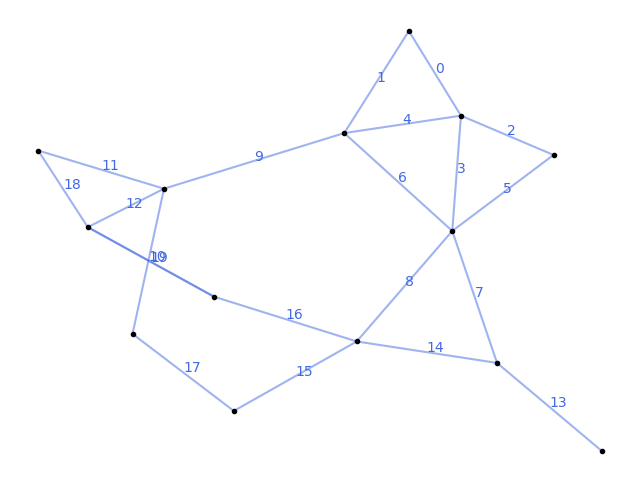

In [78]:
G, node_pair2id= graph.from_A_to_G(A[:, :])
G, _= graph.from_A_to_G(A[:, :])
print("num links")
print(G.number_of_edges())
print(m)
print("num links")
G= G.to_undirected()
biconnected_components = list(nx.biconnected_components(G))
largest_bcc = list(max(biconnected_components, key=len))
plotGraph.plot_spring_layout(G, label= False, label_edge= True, node_pair2id= node_pair2id)